In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel))
library(tidyr)
library(foreach)
library(doParallel)
library(tidygraph)
library(anndata)
suppressMessages(library(cowplot))
# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)



载入程序包：‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing


载入需要的程序包：iterators


载入程序包：‘tidygraph’


The following object is masked from ‘package:igraph’:

    groups


The following object is masked from ‘package:stats’:

    filter



载入程序包：‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers




In [2]:
data1 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/STN.h5ad')

seurat = CreateSeuratObject(counts = t(data1$X),meta.data = data1$obs)

seurat

Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”


An object of class Seurat 
20240 features across 84529 samples within 1 assay 
Active assay: RNA (20240 features, 0 variable features)
 1 layer present: counts

In [9]:
seurat@meta.data %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,Species,Animal,sample_name,Library,main.structure,area,path,matrix_dir
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
cDNA-250114094:CELL1_N5,SeuratProject,1429,956,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL2_N4,SeuratProject,1504,1006,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL3_N2,SeuratProject,15703,5051,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL5_N4,SeuratProject,1531,972,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL7_N5,SeuratProject,2675,1713,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix
cDNA-250114094:CELL8_N5,SeuratProject,4121,2113,macaque,Mq246,MQ246A-115,cDNA-250114094,Midbrain,VTA,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250114094/output/filter_matrix


In [3]:

cellNum2 <- ncol(seurat) # nolint
cellNum2
sample_cellNum <- table(seurat$Library)

[1] 84529

In [4]:
seurat$countFeatureRatio <- seurat$nCount_RNA / seurat$nFeature_RNA
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
seurat[["percent.mt"]] <- colSums(x = GetAssayData(object = seurat, assay = "RNA", layer = "counts")
    [MTGenes, , drop = FALSE])/seurat[[paste0("nCount_","RNA")]] * 100

In [5]:
seurat = subset(seurat, nFeature_RNA > 300 & percent.mt < 5 
& countFeatureRatio > 1.2
& countFeatureRatio < 10000
& nCount_RNA < 50000)
cellNum1 = ncol(seurat)
message("Filter ratio: ", cellNum1/cellNum2)
sample_cellNum_filter <- table(seurat$Library)
sample_ratial <- sample_cellNum_filter / sample_cellNum
sample_ratial

Filter ratio: 0.983224692117498




cDNA-250114076 cDNA-250114077 cDNA-250114078 cDNA-250114079 cDNA-250114080 
     0.9776291      0.9715251      0.9876940      0.9878863      0.9888961 
cDNA-250114081 
     0.9869835 

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


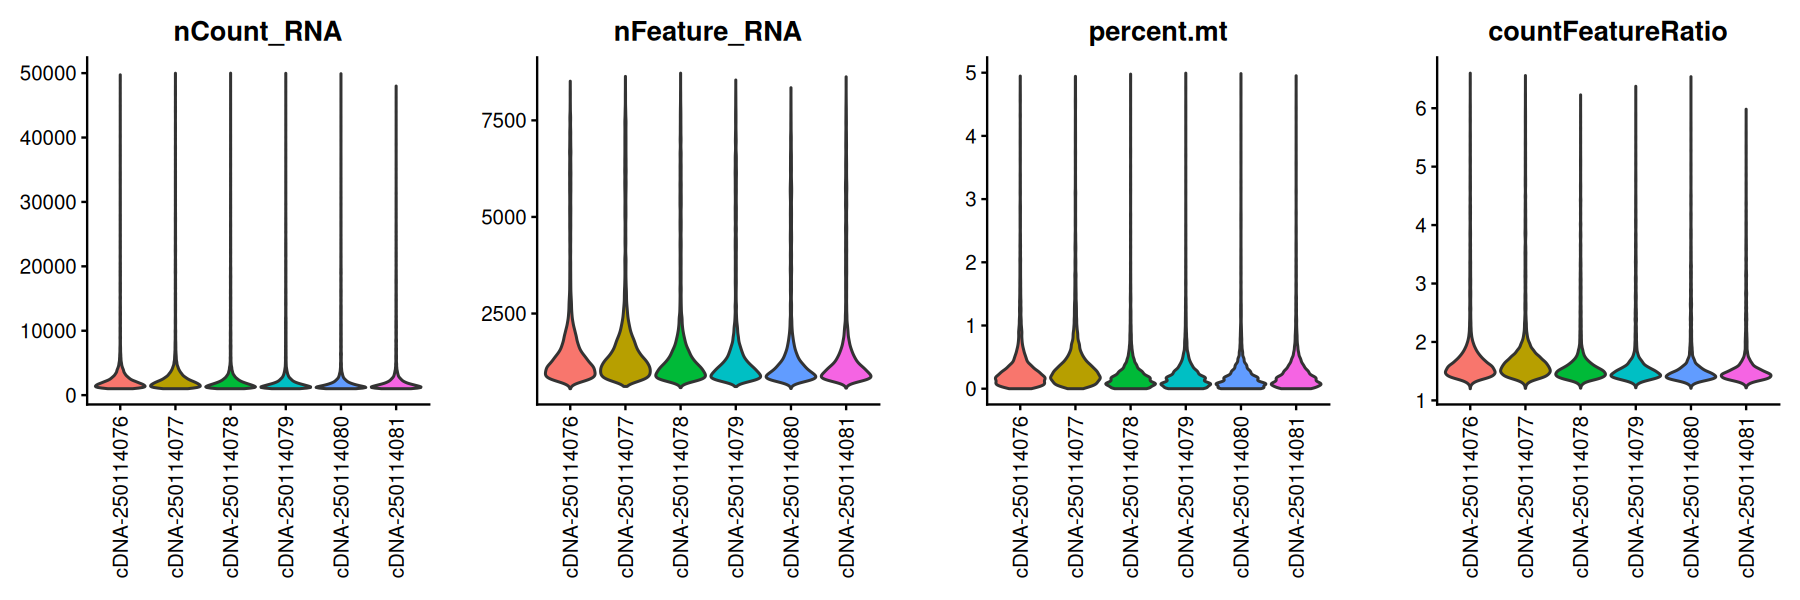

In [6]:
Idents(seurat) = "Library"
options(repr.plot.width=15, repr.plot.height=5)
print(plot_grid(
    plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt", "countFeatureRatio"), function(x) {
        p = VlnPlot(seurat, features=x, pt.size=0) + 
            theme(axis.text.x=element_text(vjust=0.5, hjust=0.5, angle=90), axis.title.x = element_blank()) +
            guides(fill=FALSE)
        return(p)
    }), 
    ncol=4, align="hv", axis="tblr"
))

In [ ]:
SCTseurat = SCTransform(
    seurat, assay="RNA",
    ncells=ncol(seurat[["RNA"]]),
    variable.features.n=3000,
    vars.to.regress="percent.mt",
    return.only.var.genes = T,
    method="glmGamPoi"
)

SCTseurat = SCTseurat %>%
    RunPCA(npcs=100, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = 0.7, random.seed = 111) %>%
    RunUMAP(dims = 1:25,umap.method = "umap-learn")

Running SCTransform on assay: RNA



vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19306 by 83111

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 83111 cells

Found 35 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19306 genes

Computing corrected count matrix for 19306 genes

Calculating gene attributes

Wall clock passed: Time difference of 5.982082 mins

Determine variable features

Regressing out percent.mt

Centering data matrix

Place corrected count matrix in counts slot

Set default assay to SCT



In [33]:
seurat_norm <- seurat %>% 
    NormalizeData(normalization.method = "LogNormalize") %>% 
    FindVariableFeatures( nfeatures = 3000) %>% 
    ScaleData()



Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix



Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4155550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4155550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4155550)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4155550)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony con

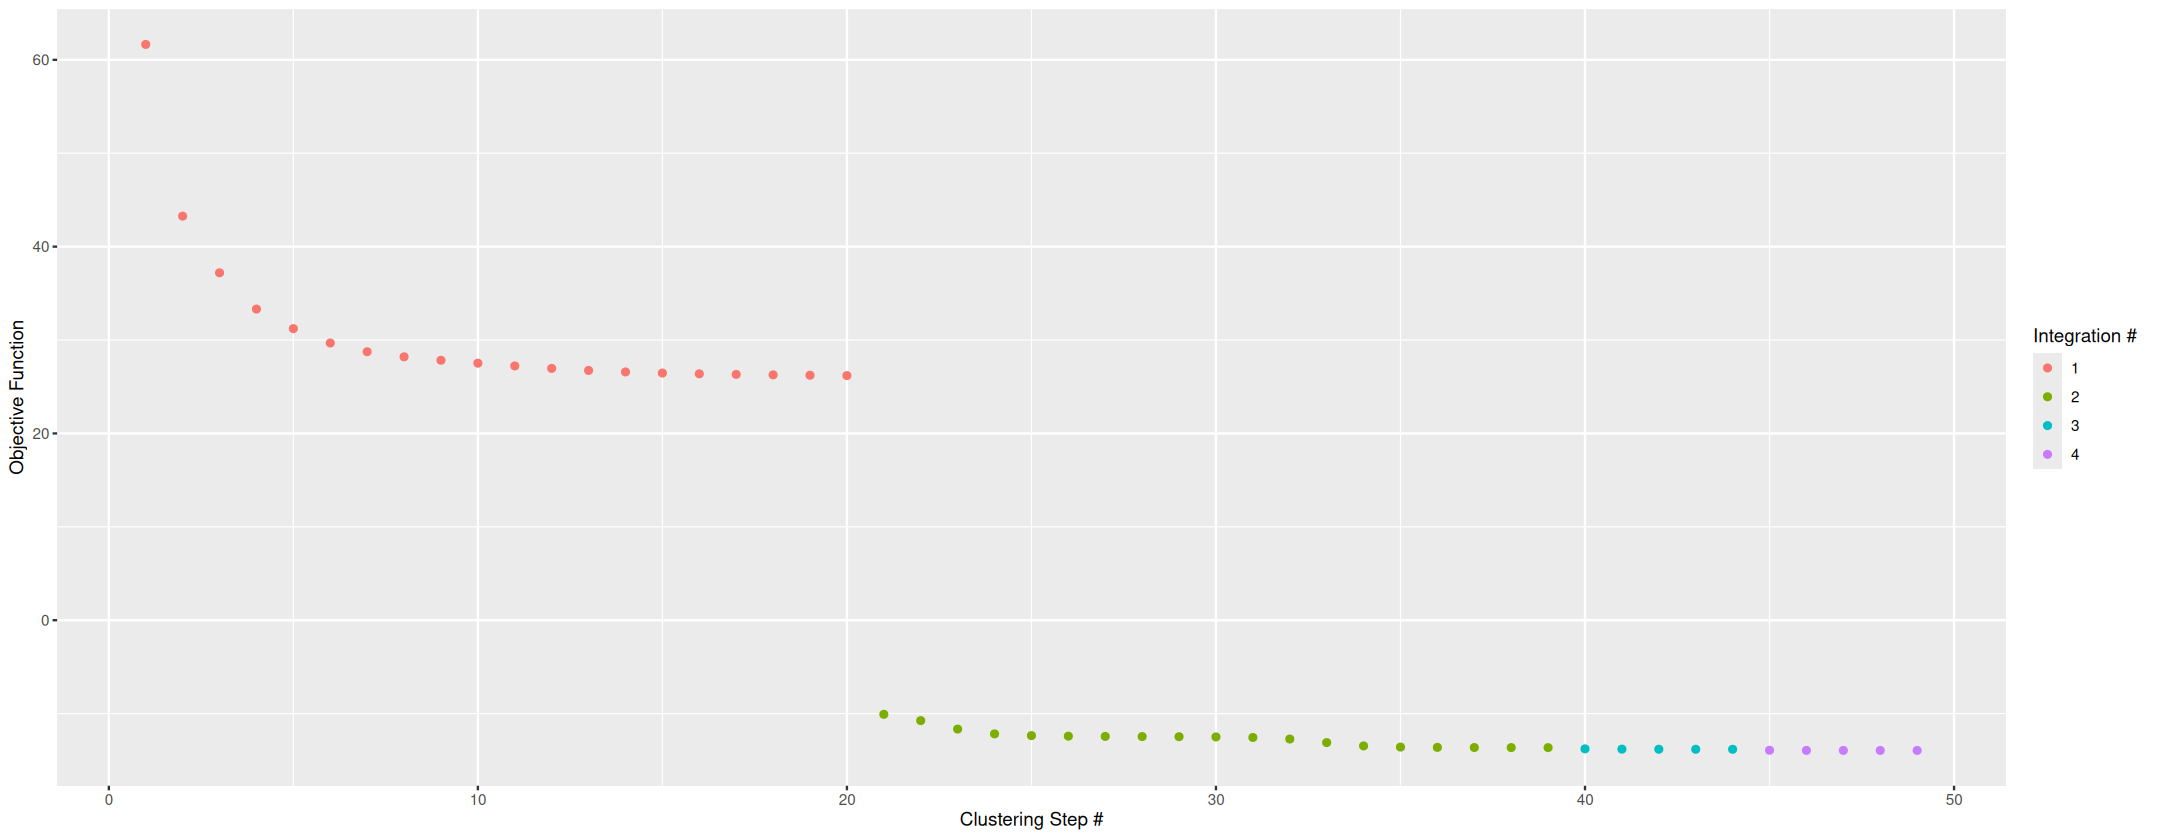

In [34]:
seurat_norm = seurat_norm %>%
    RunPCA(npcs=100, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = 0.7, random.seed = 111) %>%
    RunUMAP(dims = 1:25,umap.method = "umap-learn")


seurat_norm_1 = RunHarmony(
    seurat_norm, group.by.vars="Animal", plot_convergence=T,
    reduction.save = "harmony", dims.use=1:25,
    theta=2)

seurat_norm_2 <- seurat_norm_1 %>%
    FindNeighbors(reduction="harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE,resolution = 0.4, random.seed = 666) %>%
    RunUMAP(reduction="harmony", dims = 1:25)


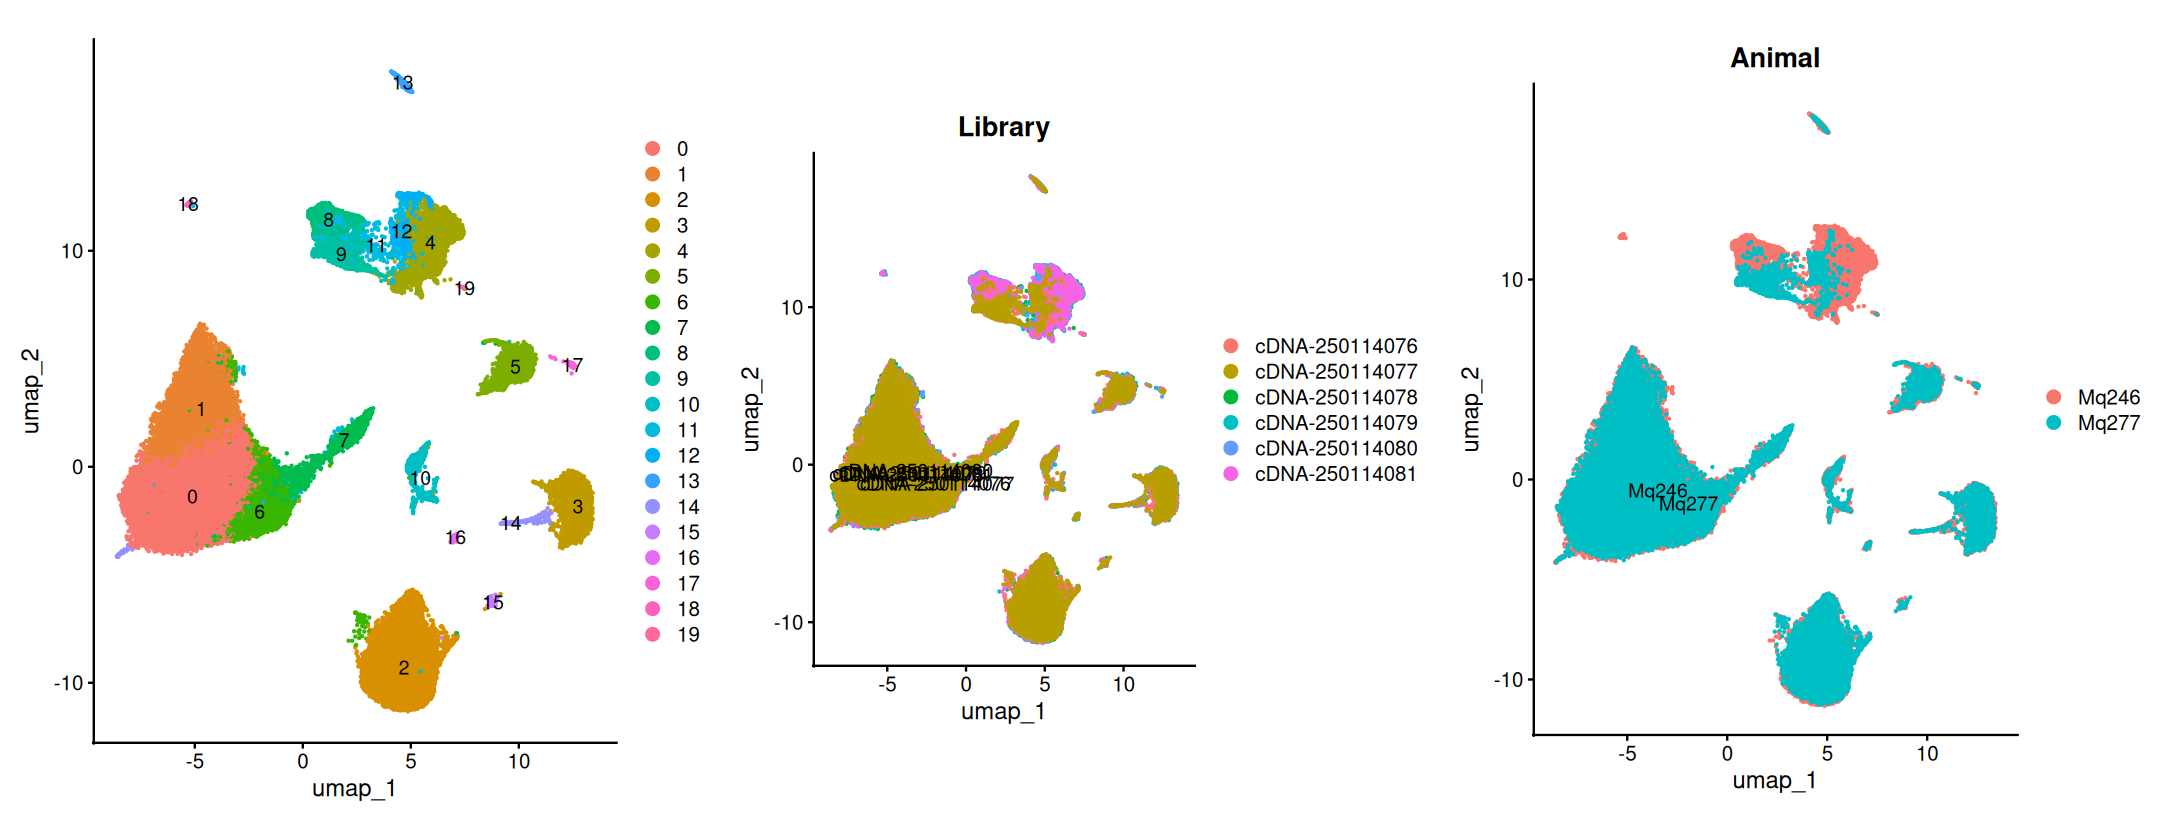

In [35]:
options(repr.plot.width=18, repr.plot.height=7)
plot_grid(
    DimPlot(seurat_norm_2, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(seurat_norm_2, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(seurat_norm_2, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [ ]:
DimPlot(seurat_norm_2, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


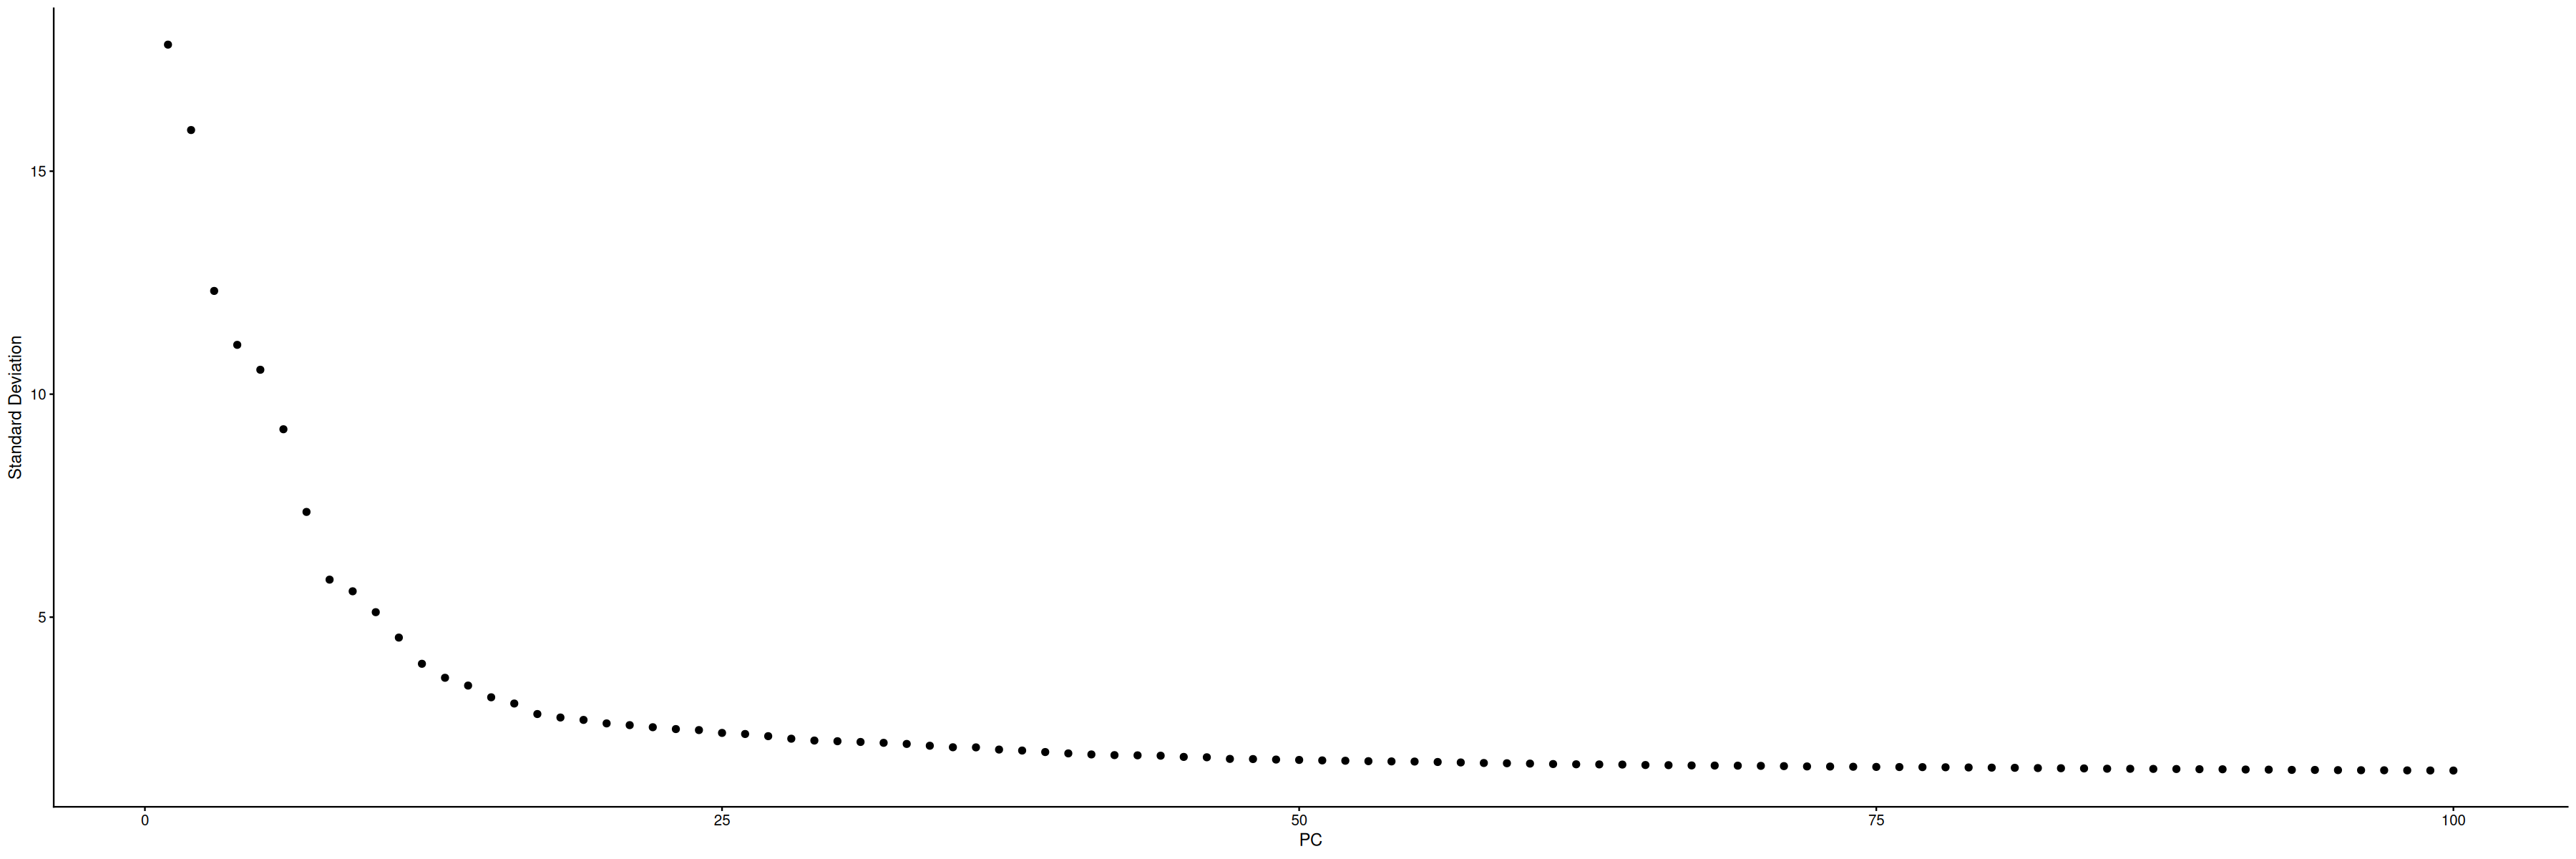

In [22]:
plot <- ElbowPlot(SCTseurat,ndims =100 , reduction = 'pca')
plot

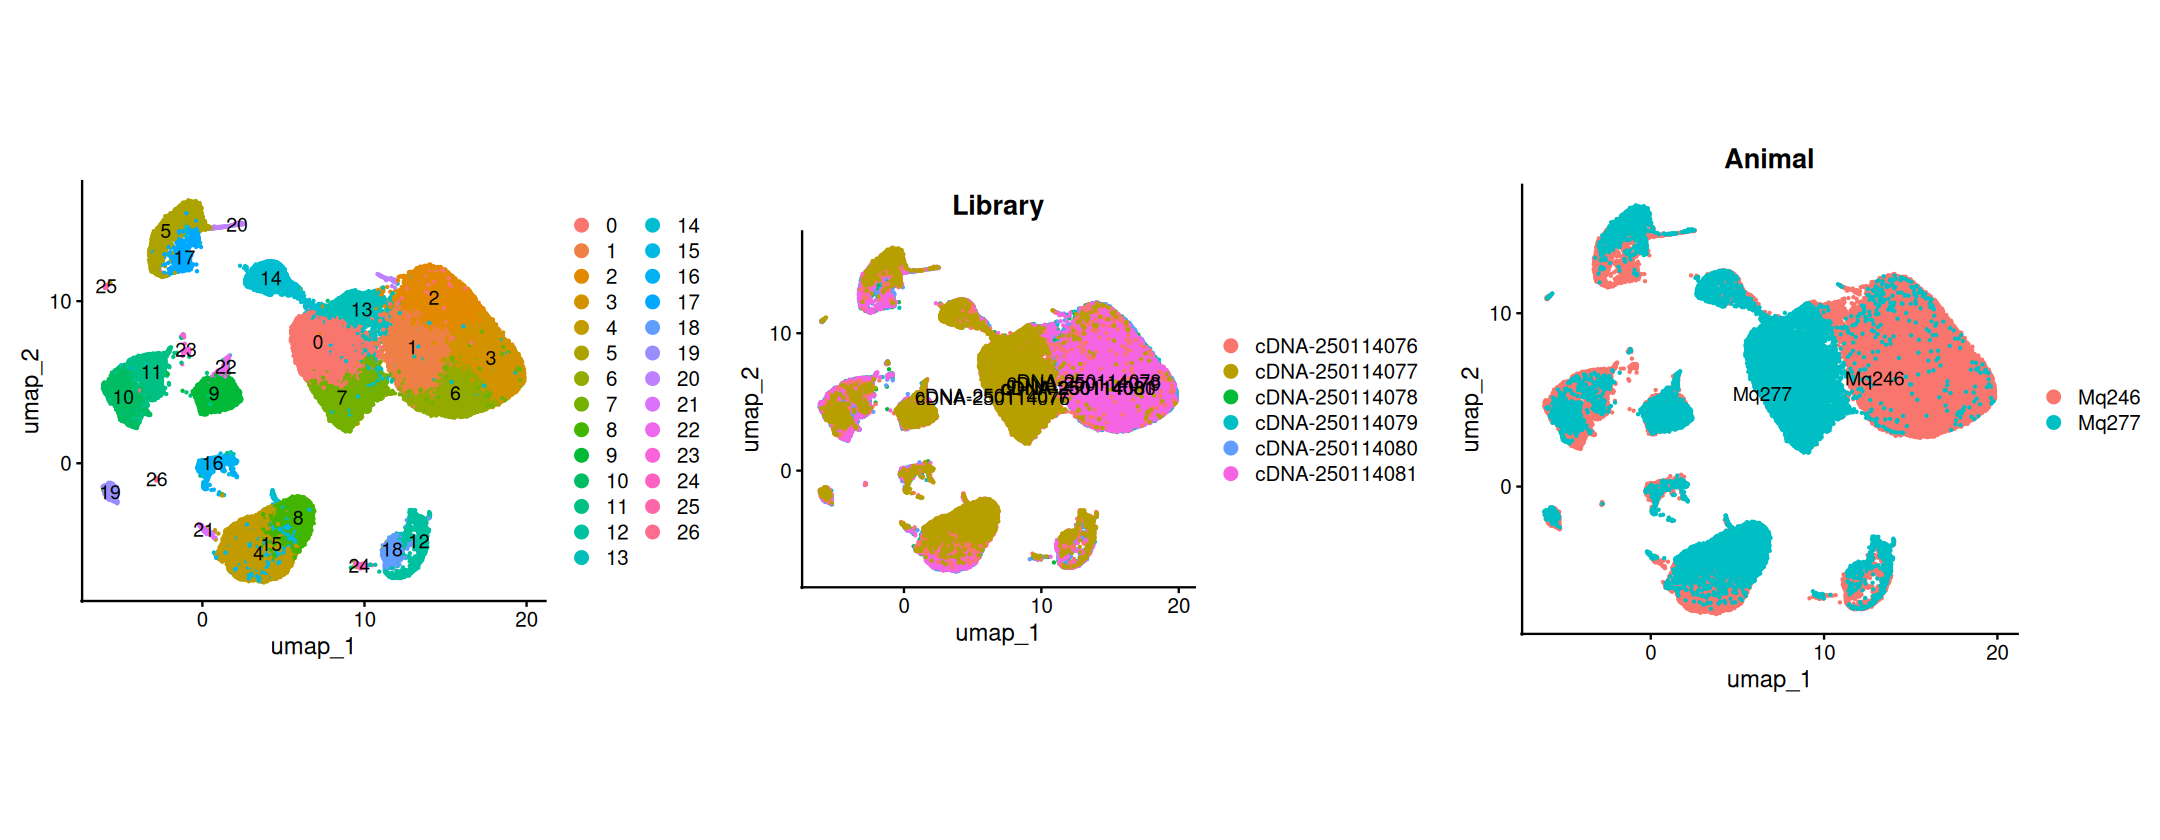

In [23]:
options(repr.plot.width=18, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [24]:
# 去批次
SCTseurat_harmony = SCTseurat %>%
    RunHarmony(group.by.vars = c("Animal"),dims.use = 1:25 ,theta = 2,reduction = "pca", max.iter.harmony = 10,sigma = 0.1,assay.use = "SCT", reduction.save = "harmony") %>%
    FindNeighbors(dims = 1:25, reduction = "harmony") %>%
    FindClusters(verbose = FALSE, resolution =0.7, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, reduction = "harmony", assay = "SCT")  

Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 4155550)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony converged after 5 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
01:46:06 UMAP embedding parameters a = 0.9922 b = 1.112

01:46:06 Read 83111 rows and found 25 numeric columns

01:46:06 Using Annoy for neighbor search, n_neighbors = 30

01:46:06 Bui

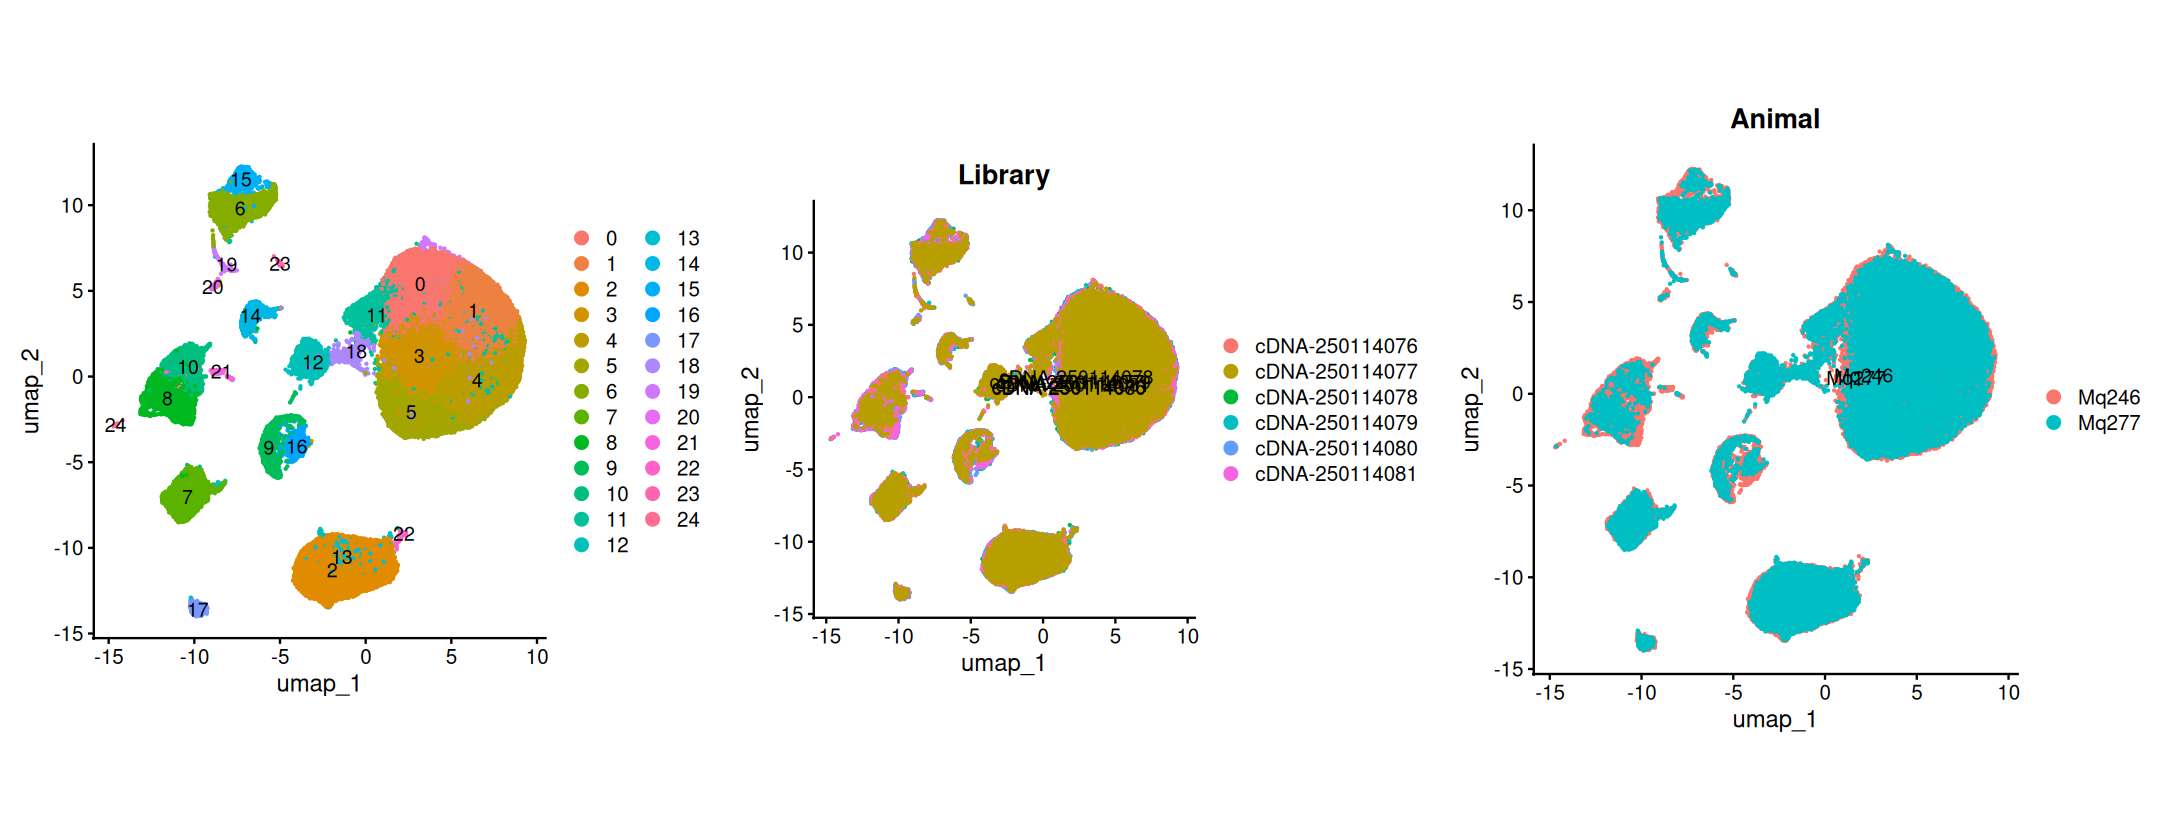

In [25]:
options(repr.plot.width=18, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat_harmony, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [29]:
df1 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/STN_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)

df1 %>% head()



,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>
cDNA-250114078:CELL1_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.70,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5284,5284 MOL NN_4,5230,0.53
cDNA-250114078:CELL2_N2,CS20230722_CLAS_31,31 OPC-Oligo,0.96,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5284,5284 MOL NN_4,5230,0.68
cDNA-250114078:CELL3_N2,CS20230722_CLAS_30,30 Astro-Epen,0.90,CS20230722_SUBC_318,318 Astro-NT NN,0.79,CS20230722_SUPT_1160,1160 Astro-NT NN_2,0.93,CS20230722_CLUS_5214,5214 Astro-NT NN_2,14956,0.64
cDNA-250114078:CELL4_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.95,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.92
cDNA-250114078:CELL5_N4,CS20230722_CLAS_31,31 OPC-Oligo,0.99,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.90
cDNA-250114078:CELL6_N4,CS20230722_CLAS_31,31 OPC-Oligo,0.85,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.93


In [38]:
df1_filt = subset(df1,class_bootstrapping_probability > 0.8)
df1
df1_filt

,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>
cDNA-250114078:CELL1_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.70,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5284,5284 MOL NN_4,5230,0.53
cDNA-250114078:CELL2_N2,CS20230722_CLAS_31,31 OPC-Oligo,0.96,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5284,5284 MOL NN_4,5230,0.68
cDNA-250114078:CELL3_N2,CS20230722_CLAS_30,30 Astro-Epen,0.90,CS20230722_SUBC_318,318 Astro-NT NN,0.79,CS20230722_SUPT_1160,1160 Astro-NT NN_2,0.93,CS20230722_CLUS_5214,5214 Astro-NT NN_2,14956,0.64
cDNA-250114078:CELL4_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.95,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.92
cDNA-250114078:CELL5_N4,CS20230722_CLAS_31,31 OPC-Oligo,0.99,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.90
cDNA-250114078:CELL6_N4,CS20230722_CLAS_31,31 OPC-Oligo,0.85,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.93
cDNA-250114078:CELL7_N2,CS20230722_CLAS_20,20 MB GABA,0.30,CS20230722_SUBC_207,207 SCs Dmbx1 Gaba,0.35,CS20230722_SUPT_0855,0855 SCs Dmbx1 Gaba_4,0.52,CS20230722_CLUS_3736,3736 SCs Dmbx1 Gaba_4,3557,0.48
cDNA-250114078:CELL8_N5,CS20230722_CLAS_31,31 OPC-Oligo,0.98,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,0.99,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.99
cDNA-250114078:CELL9_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.97,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.93


,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>
cDNA-250114078:CELL2_N2,CS20230722_CLAS_31,31 OPC-Oligo,0.96,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5284,5284 MOL NN_4,5230,0.68
cDNA-250114078:CELL3_N2,CS20230722_CLAS_30,30 Astro-Epen,0.90,CS20230722_SUBC_318,318 Astro-NT NN,0.79,CS20230722_SUPT_1160,1160 Astro-NT NN_2,0.93,CS20230722_CLUS_5214,5214 Astro-NT NN_2,14956,0.64
cDNA-250114078:CELL4_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.95,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.92
cDNA-250114078:CELL5_N4,CS20230722_CLAS_31,31 OPC-Oligo,0.99,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.90
cDNA-250114078:CELL6_N4,CS20230722_CLAS_31,31 OPC-Oligo,0.85,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.93
cDNA-250114078:CELL8_N5,CS20230722_CLAS_31,31 OPC-Oligo,0.98,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,0.99,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.99
cDNA-250114078:CELL9_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.97,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.93
cDNA-250114078:CELL10_N2,CS20230722_CLAS_31,31 OPC-Oligo,0.99,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.84
cDNA-250114078:CELL11_N2,CS20230722_CLAS_31,31 OPC-Oligo,0.94,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5284,5284 MOL NN_4,5230,0.50


In [39]:
seurat_norm_3 = seurat_norm_2

seurat_norm_3$Mouse_anno = c(df1_filt$class_name)

In [41]:
seurat_norm_3_filt = subset(
  seurat_norm_3,
  subset = !(Mouse_anno %in% c("30 Astro-Epen", "31 OPC-Oligo"))
)
seurat_norm_3_filt
seurat_norm_3

An object of class Seurat 
20240 features across 3851 samples within 1 assay 
Active assay: RNA (20240 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

An object of class Seurat 
20240 features across 83111 samples within 1 assay 
Active assay: RNA (20240 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

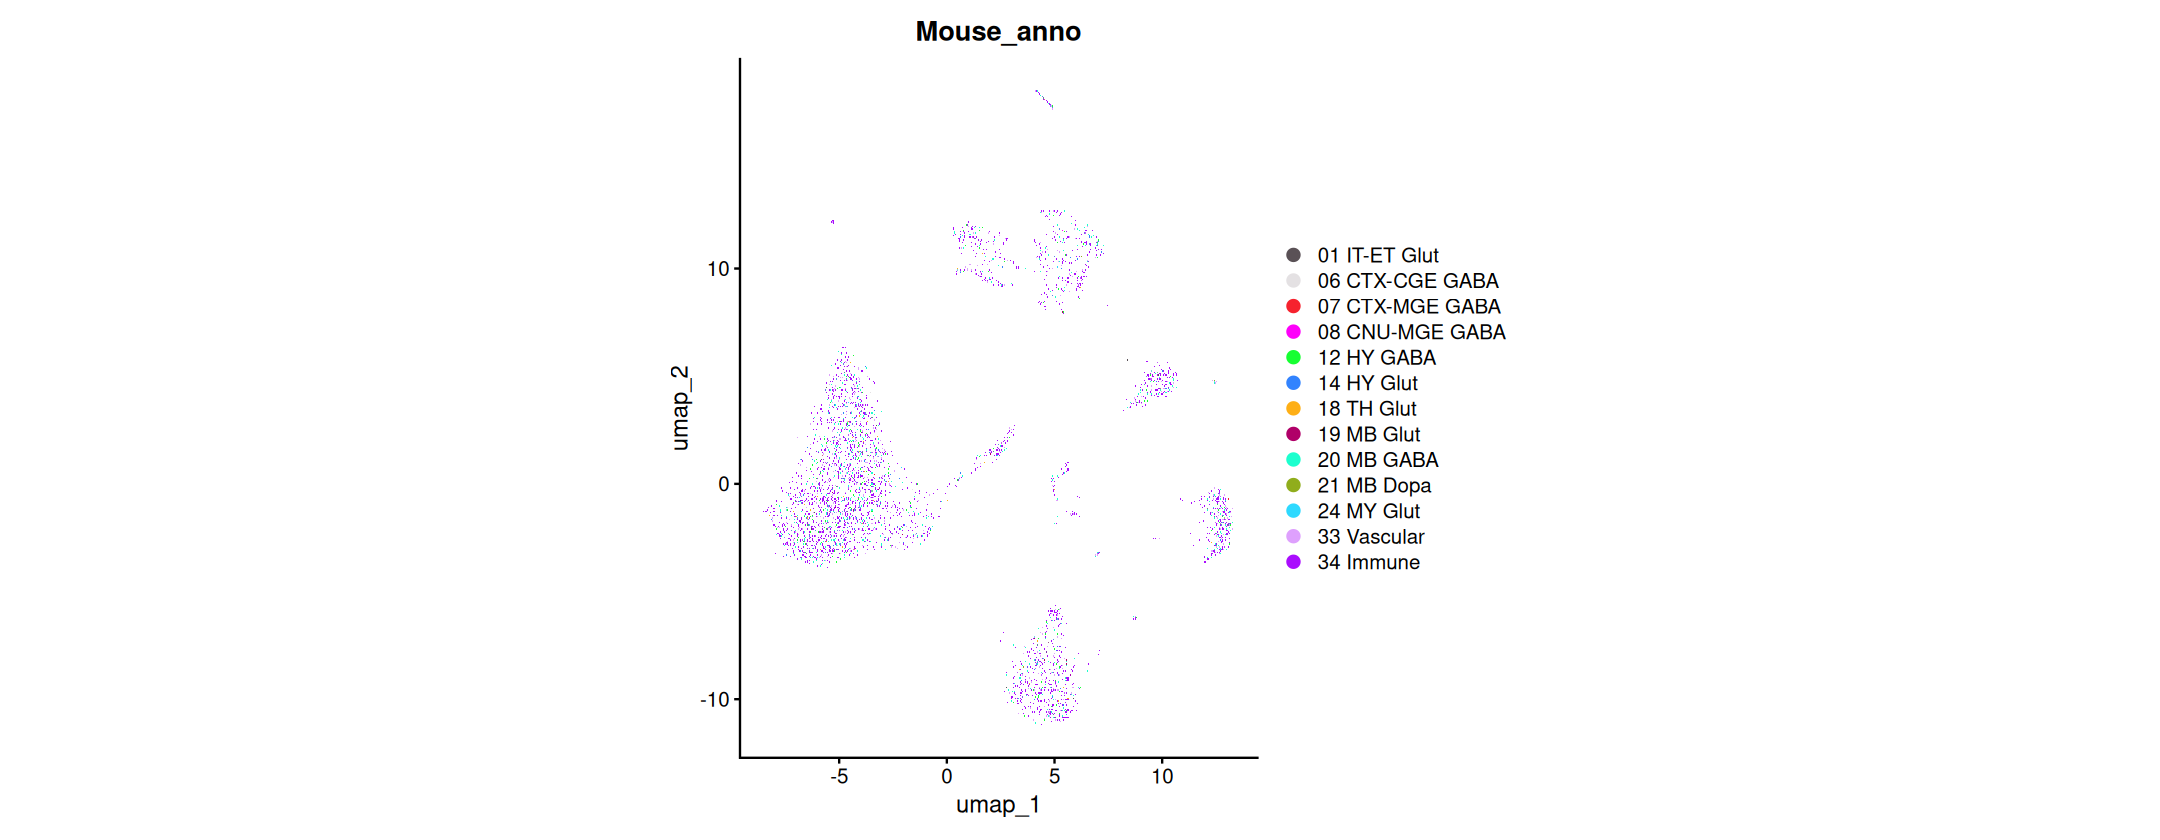

In [42]:
options(repr.plot.width=18, repr.plot.height=7)

human_anno_levels = sort(unique(na.omit(seurat_norm_3_filt$Mouse_anno)))
human_anno_cols = setNames(
  DiscretePalette(length(human_anno_levels), palette = "polychrome"),
  human_anno_levels
)

DimPlot(
  seurat_norm_3_filt,
  reduction = "umap",
  group.by = "Mouse_anno",
  label = F,
  raster = T,
  cols = human_anno_cols
) + coord_fixed()

In [30]:
SCTseurat_harmony_2 = SCTseurat_harmony

SCTseurat_harmony_2$Mouse_anno = c(df1$class_name)

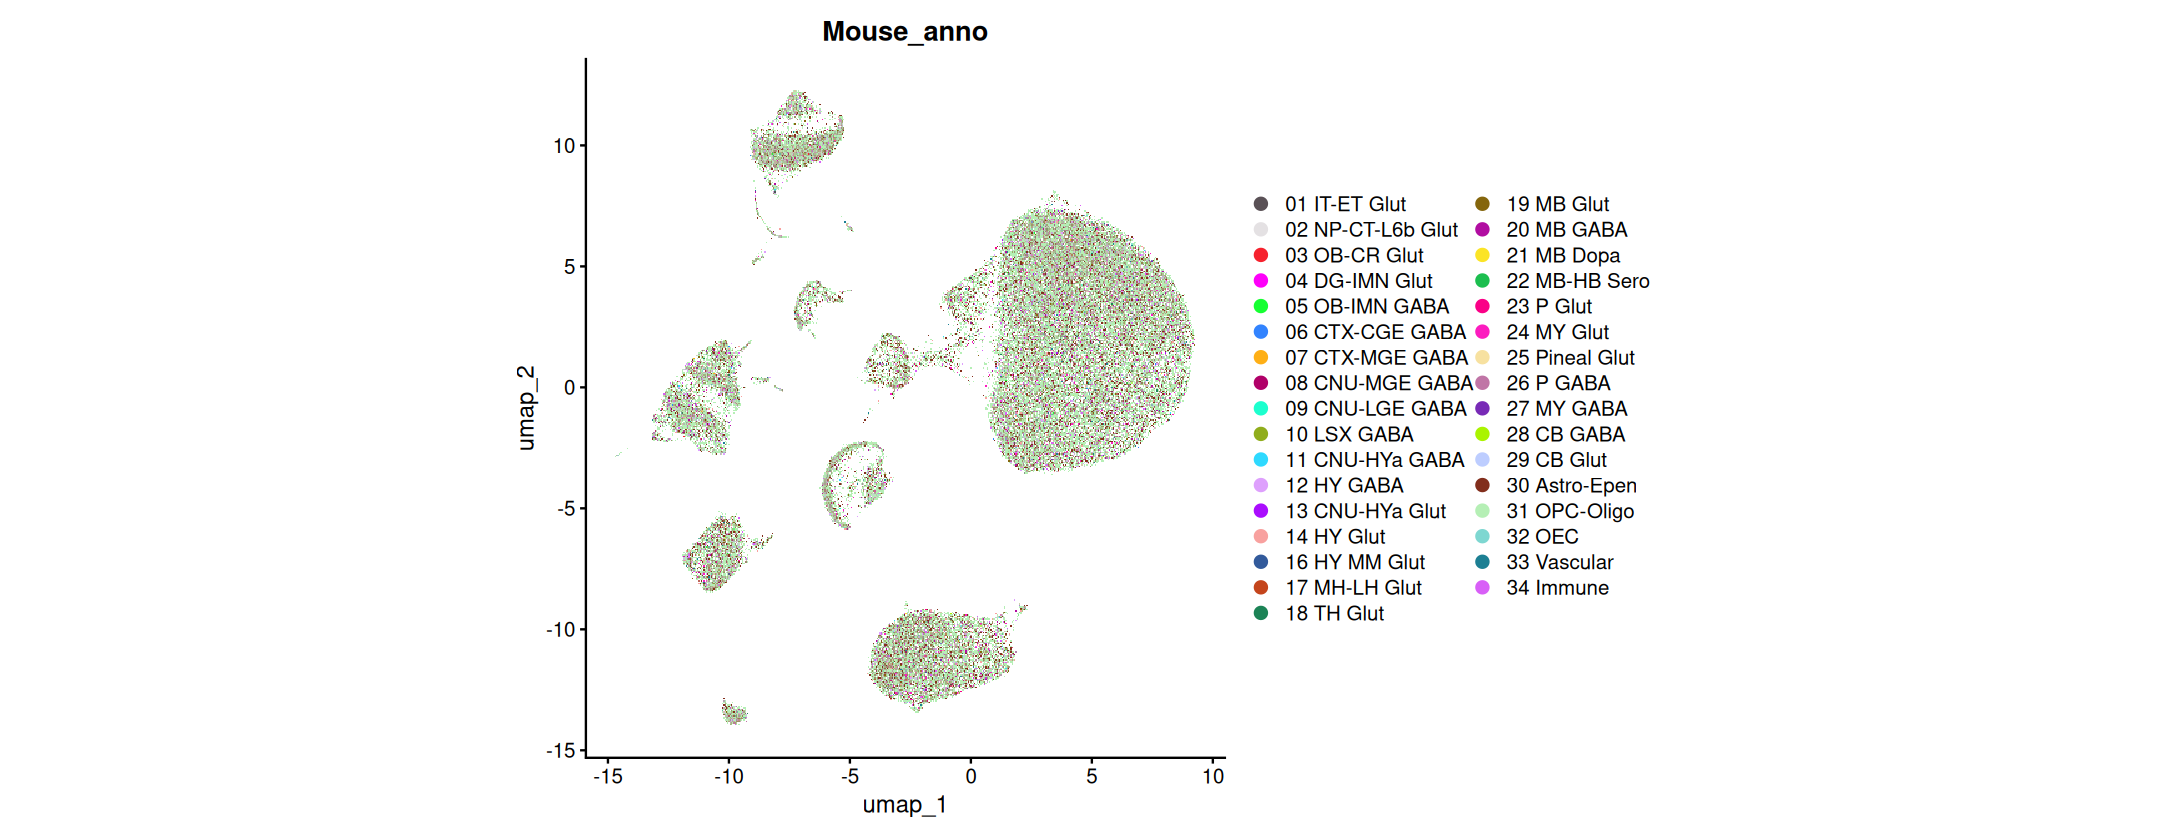

In [32]:
options(repr.plot.width=18, repr.plot.height=7)

human_anno_levels = sort(unique(na.omit(SCTseurat_harmony_2$Mouse_anno)))
human_anno_cols = setNames(
  DiscretePalette(length(human_anno_levels), palette = "polychrome"),
  human_anno_levels
)

DimPlot(
  SCTseurat_harmony_2,
  reduction = "umap",
  group.by = "Mouse_anno",
  label = F,
  raster = T,
  cols = human_anno_cols
) + coord_fixed()

In [26]:
SCTseurat_harmony

An object of class Seurat 
39546 features across 83111 samples within 2 assays 
Active assay: SCT (19306 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

In [43]:
Excit = c("SNAP25","SLC17A6",'NTNG1' , "RBFOX3","NEFM","NEFH","NEFL","STMN2","SERPINF1","SNCG","BHLHE22","ANXA6","TUBA4A","NRN1")

Inhib = c("GAD1", "GAD2",'DLX6','ADARB2',"FBXL7","KIT","EYA4","TRPS1")


Astrocytes = c("SLC1A2","SLC1A3","S100B", "AQP4", "APOE",'GJA1','ALDH1L1','AGT','EDNRB' ,"GFAP")
Ependymal = c("FOXJ1", "PIFO", "DYNLRB2", "RSPH1", "DNAH12", "FAM216B", "ZMYDN10", "IQCG", "ENKUR","LRRC23" )

Endotheial = c("PECAM1","VWF","CD34","VECAD" ,"CLDN5","KDR","CD105",'FLT1','RAMP2','GNG11' )
# Pericytes = c("PDGFRB", "MCAM", "RGS5", "ALPHA-SMA", "KCNJ8",'TAGLN','COX4l2','MOTCH3','ABCC9' )
OPC = c("ABRACL", "PDGFRALPHA", "OLIG2", "CSPG4", "OLIG1", "VCAN",'LHFPL3','SOX6','GPR17','BCAN',"PTPRZ1","PDGFRA","COL9A1" )
Oligo = c("PLP1",'MOG','MOBP','CLDN11','MAG','CNP','PTGDS','GPR37','FA2H','APOD' )
Microglia = c('CD68','C1QB','OLR1','HAVCR2','C1QC','CSF3R','CS3CR1','P2RY12','SALL1','TLR2',"ITGAM")

Warning message:
“Could not find BHLHE22 in the default search locations, found in ‘RNA’ assay instead”
Warning message:
“No layers found matching search pattern provided”
Warning message in FetchData.Assay5(object = object[[assay]], vars = keyed.var, :
“data layer is not found and counts layer is used”
Warning message:
“The following requested variables were not found: AQP4, GJA1, DNAH12, ZMYDN10, IQCG, VECAD, CD105, PDGFRALPHA, CS3CR1”


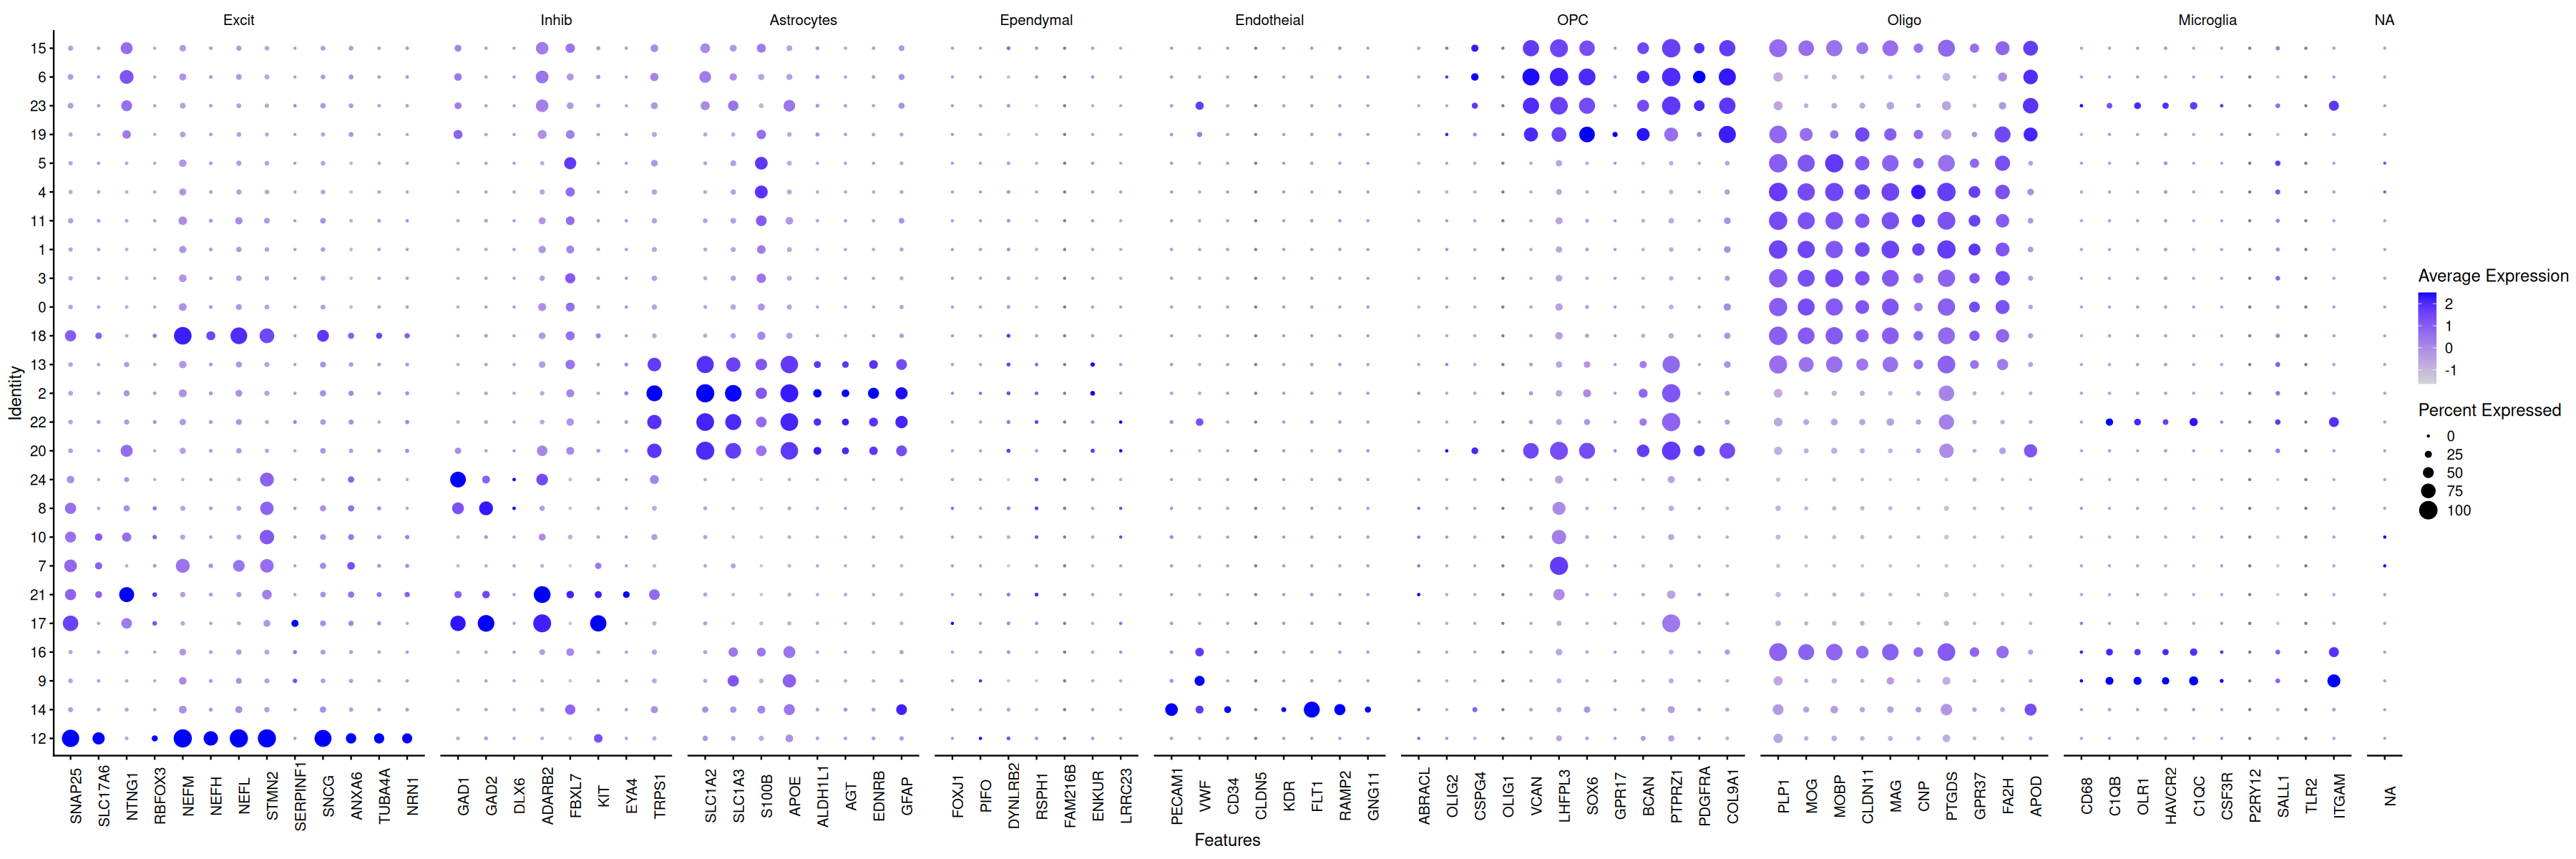

In [45]:
# selectMarkers=selectMarkers[!duplicated(selectMarkers)]
Idents(SCTseurat_harmony) = "seurat_clusters"
options(repr.plot.height=10,repr.plot.width=30)
features <- list(
"Excit" = Excit, 
# "layer"=layer,"deep_layer"=deep_layer, "L4_IT"=L4_IT , "L5_ET"=L5_ET , "L5_IT"=L5_IT,
# "L5_6_NP"=L5_6_NP , "L6_CT"=L6_CT , "L6_IT_CAR3"=L6_IT_CAR3 , "L6_IT"=L6_IT,"L6b"=L6b,
"Inhib" = Inhib, 
# "RELN"=RELN,"SST"=SST,
"Astrocytes" = Astrocytes, 
"Ependymal" = Ependymal,  "Endotheial" = Endotheial,
"OPC" = OPC,"Oligo" = Oligo,"Microglia" = Microglia 
)

features=features[!duplicated(features)]

DotPlot(SCTseurat_harmony, features = features, cluster.idents=T) + theme(axis.text.x = element_text(angle = 90))
